## 1. Install

In [4]:
!pip install -q ultralytics roboflow pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.6 MB/s eta 0:00:00


## 2. Imports

In [5]:
import os, glob, yaml, shutil
from collections import Counter, defaultdict
from getpass import getpass
import matplotlib.pyplot as plt
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Roboflow login

In [6]:
API_KEY = getpass("Enter Roboflow API key: ")
rf = Roboflow(api_key=API_KEY)

#N24lGL6afJnL3FGyt48g

Enter Roboflow API key: ··········


## 4. Download

In [7]:
!pip install roboflow

project = rf.workspace("mohammad-hamza-sadiq").project("waste-detection-0ianf")
version = project.version(1)
dataset = version.download("yolo26")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to waste-detection-1 in yolo26:: 100%|██████████| 1984/1984 [00:00<00:00, 7582.25it/s]


In [8]:
DATASET_DIR = dataset.location
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
print(DATASET_DIR)

/content/waste-detection-1


## 5. Check classes

In [9]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

['Paper', 'Plastic']


## 6. Dataset counts

In [10]:
for split in ["train", "valid", "test"]:
    print(split, ":", len(glob.glob(f"{DATASET_DIR}/{split}/images/*")))

train : 693
valid : 198
test : 99


## 7. Object counts

In [11]:
def names_list(names):
    if isinstance(names, dict):
        return [names.get(i, names.get(str(i))) for i in range(len(names))]
    return list(names)

class_list = names_list(class_names)
class_counts = Counter()
images_per_class = defaultdict(set)
total_images = 0

for split in ["train", "valid", "test"]:
    total_images += len(glob.glob(f"{DATASET_DIR}/{split}/images/*"))

    for label_file in glob.glob(f"{DATASET_DIR}/{split}/labels/*.txt"):
        seen = set()

        for line in open(label_file):
            parts = line.split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[cid] += 1
            seen.add(cid)

        for cid in seen:
            images_per_class[cid].add(label_file)

total_objects = sum(class_counts.values())

print("Total images:", total_images)
print("Total objects:", total_objects)
print("Average objects/image:", round(total_objects / total_images, 2))

for i, name in enumerate(class_list):
    print(f"{name}: {class_counts[i]} objects | {len(images_per_class[i])} images")


Total images: 990
Total objects: 1381
Average objects/image: 1.39
Paper: 133 objects | 132 images
Plastic: 1248 objects | 860 images


## 8. Class chart

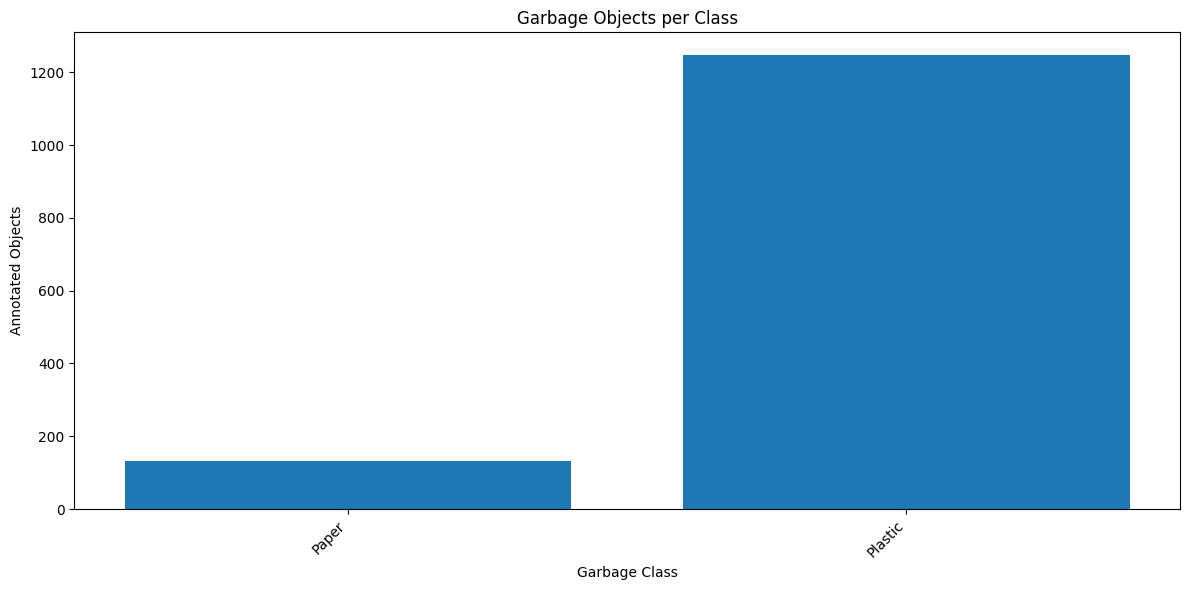

In [12]:
counts = [class_counts[i] for i in range(len(class_list))]

plt.figure(figsize=(12, 6))
plt.bar(class_list, counts)
plt.xlabel("Garbage Class")
plt.ylabel("Annotated Objects")
plt.title("Garbage Objects per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Baseline


image 1/1 /content/waste-detection-1/test/images/person-collecting-plastic-waste-polluted-beach-using-litter-picker-close-up-person-collecting-plastic-waste-polluted-116704499_jpg.rf.1b20389d479cb807184ca3945b5b5ea8.jpg: 640x640 (no detections), 485.0ms
Speed: 25.8ms preprocess, 485.0ms inference, 6.8ms postprocess per image at shape (1, 3, 640, 640)


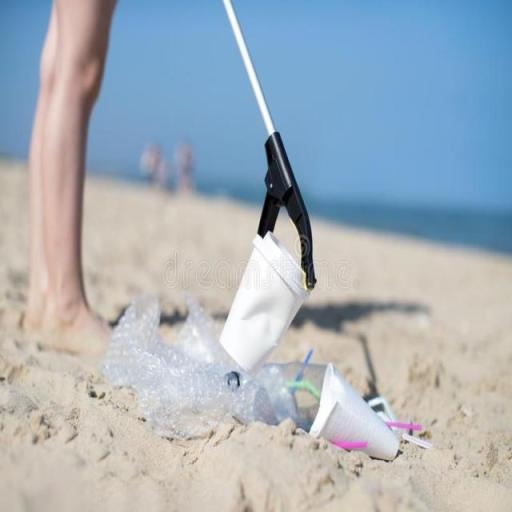

In [13]:
model = YOLO("yolo26n.pt")

test_images = glob.glob(f"{DATASET_DIR}/test/images/*")
if not test_images:
    raise ValueError("No test images found.")

baseline = model(test_images[0])
baseline[0].show()


## 10. Train with early stopping

In [16]:
shutil.rmtree("/content/runs/garbage_detection/v1", ignore_errors=True)

model = YOLO("yolo26n.pt")

model.train(
    data=yaml_path,
    epochs=5,
    imgsz=640,
    batch=8,
    patience=15,
    project="/content/runs/garbage_detection",
    name="v1"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/waste-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1, nbs=64, nms=False, ops

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7935297681d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## 11. Load best model

In [23]:
best_path = "/content/runs/garbage_detection/v1/weights/best.pt"
v1_model = YOLO(best_path)
print(v1_model.names)

{0: 'Paper', 1: 'Plastic'}


## 12. Evaluate

In [24]:
metrics = v1_model.val(data=yaml_path, split="test")

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))


Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 47.2±57.7 MB/s, size: 29.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/waste-detection-1/test/labels... 99 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 99/99 762.6it/s 0.1s
val: New cache created: /content/waste-detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.7s/it 25.8s
                   all         99        130      0.579      0.692      0.679      0.533
                 Paper         17         17      0.612      0.765       0.75      0.632
               Plastic         82        113      0.547      0.619      0.608      0.434
S

## 13. Per-class mAP50-95

In [25]:
for name, score in zip(v1_model.names.values(), metrics.box.maps):
    print(name, ":", round(float(score), 4))


Paper : 0.6318
Plastic : 0.4336


## 14. Test images


0: 640x640 (no detections), 187.9ms
1: 640x640 2 Plastics, 187.9ms
2: 640x640 (no detections), 187.9ms
3: 640x640 1 Plastic, 187.9ms
4: 640x640 1 Plastic, 187.9ms
5: 640x640 3 Plastics, 187.9ms
6: 640x640 5 Plastics, 187.9ms
7: 640x640 1 Plastic, 187.9ms
8: 640x640 2 Plastics, 187.9ms
9: 640x640 1 Paper, 1 Plastic, 187.9ms
Speed: 4.6ms preprocess, 187.9ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)


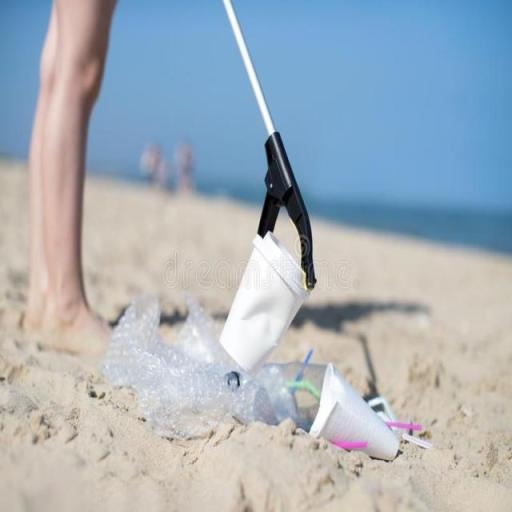

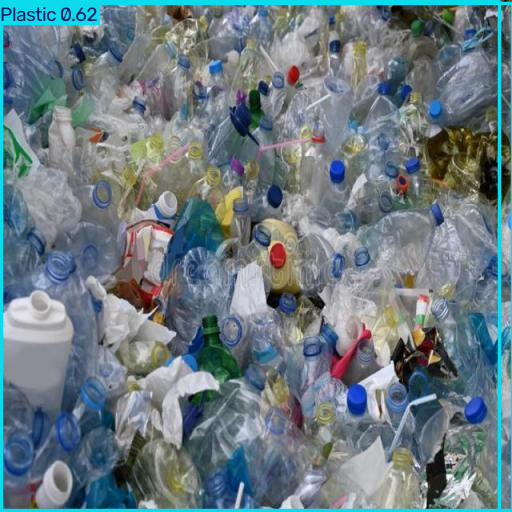

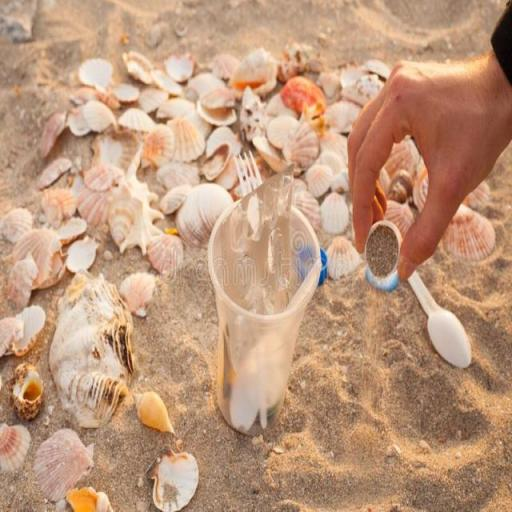

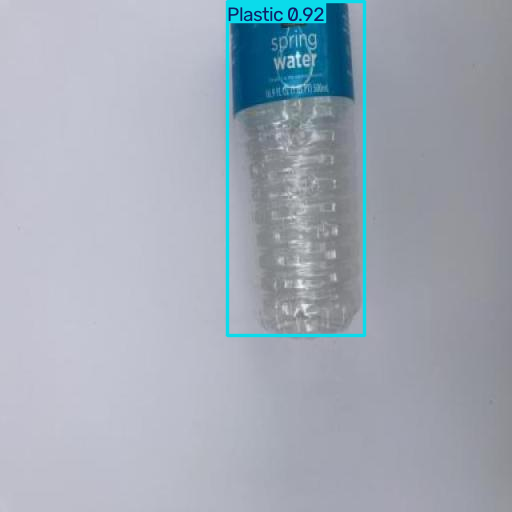

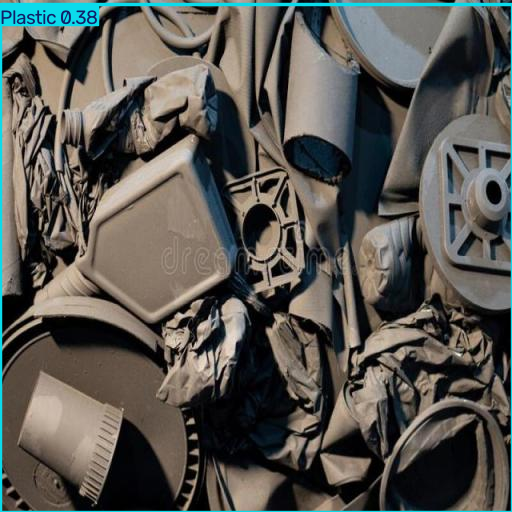

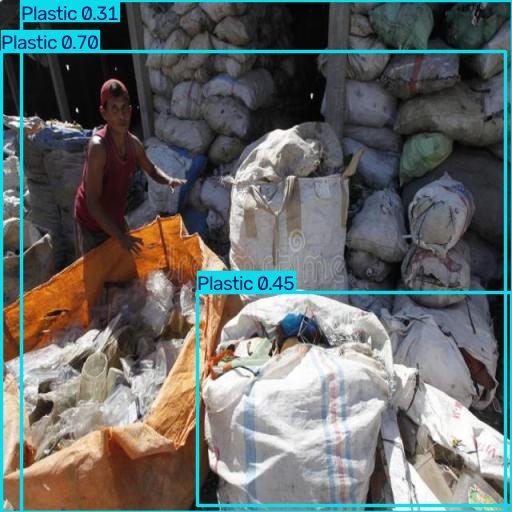

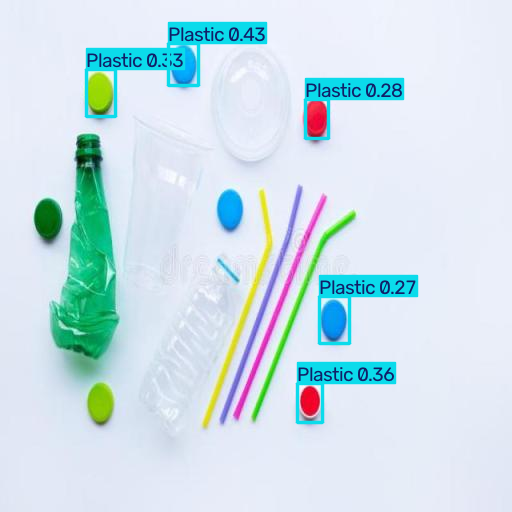

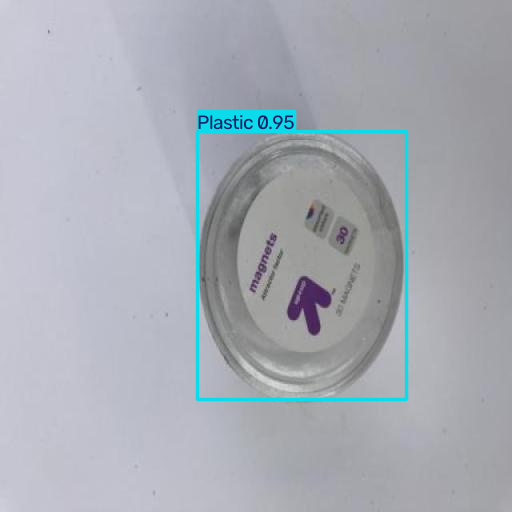

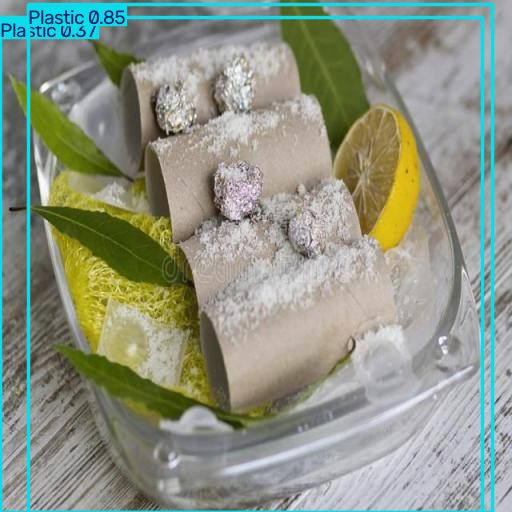

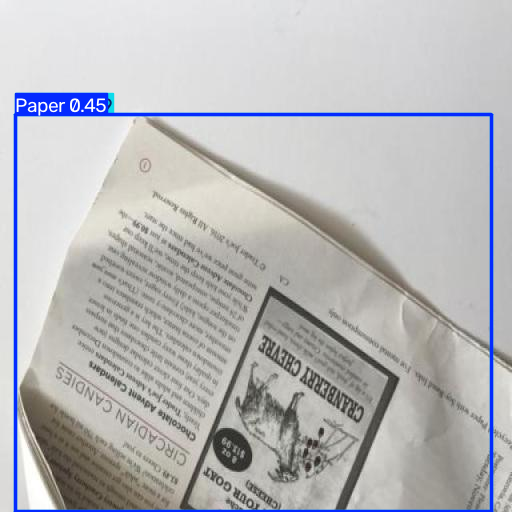

In [26]:
results = v1_model(test_images[:10], conf=0.25)

for result in results:
    result.show()


## 15. Camera setup

In [27]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript, display

def take_photo(filename="camera_test.jpg"):
    js = Javascript("""
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');

      button.textContent = 'Take Photo';
      div.appendChild(video);
      div.appendChild(document.createElement('br'));
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    """)

    display(js)
    data = eval_js("takePhoto()")
    binary = b64decode(data.split(",")[1])

    with open(filename, "wb") as f:
        f.write(binary)

    return filename


## 16. Camera detection

<IPython.core.display.Javascript object>


image 1/1 /content/camera_test.jpg: 480x640 2 Plastics, 138.1ms
Speed: 2.4ms preprocess, 138.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


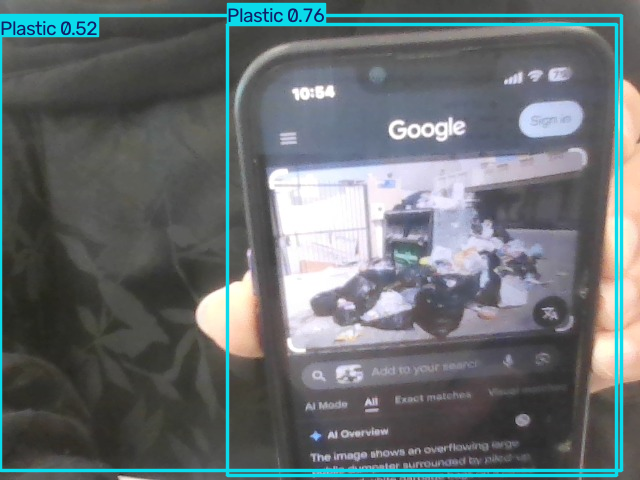

Plastic 76.3%
Plastic 51.5%


In [30]:
camera_image = take_photo()

result = v1_model(camera_image, conf=0.25)
result[0].show()

if len(result[0].boxes) == 0:
    print("No detections.")
else:
    for box in result[0].boxes:
        cid = int(box.cls[0])
        conf = float(box.conf[0])
        print(v1_model.names[cid], f"{conf * 100:.1f}%")